# TP Final - Pensamiento Computacional
## Análisis de Universidades y Barrios de CABA

**Objetivo:** Analizar la distribución de universidades en los barrios de la Ciudad de Buenos Aires y determinar qué zonas concentran la mayor oferta educativa.

In [1]:
# Instalación de dependencias
!pip install geopandas matplotlib openpyxl -q

In [2]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (10,6)

## Carga de archivos

In [9]:
from google.colab import files
uploaded = files.upload()

# Subir barrios.zip y universidades.zip antes de continuar

Saving barrios.zip to barrios (1).zip
Saving universidades.zip to universidades (2).zip


In [10]:
import zipfile, os

for archivo in os.listdir():
    if archivo.endswith('.zip'):
        with zipfile.ZipFile(archivo, 'r') as z:
            z.extractall(archivo.replace('.zip',''))

In [11]:
import glob

barrios_shp = glob.glob('**/*barri*.shp', recursive=True)[0]
universidades_shp = glob.glob('**/*univ*.shp', recursive=True)[0]

barrios = gpd.read_file(barrios_shp)
universidades = gpd.read_file(universidades_shp)

print('Barrios:', len(barrios))
print('Universidades:', len(universidades))

Barrios: 48
Universidades: 153


## Análisis exploratorio

In [12]:
display(barrios.head())
display(universidades.head())

,id,objeto,nombre,comuna,perimetro_,area_metro,geometry
0,1,BARRIO,AGRONOMIA,15,6556.17,2122169.54,"POLYGON ((-58.47589 -34.59173, -58.47598 -34.5..."
1,2,BARRIO,ALMAGRO,5,8537.90,4050752.63,"POLYGON ((-58.416 -34.59786, -58.4157 -34.5978..."
2,3,BARRIO,BALVANERA,3,8375.82,4342280.68,"POLYGON ((-58.39294 -34.59964, -58.39277 -34.6..."
3,4,BARRIO,BARRACAS,4,12846.58,7955144.83,"POLYGON ((-58.37066 -34.6295, -58.37064 -34.62..."
4,5,BARRIO,BELGRANO,13,20430.59,8060009.10,"POLYGON ((-58.45167 -34.53565, -58.45168 -34.5..."


,id,nombre,unidad_aca,sede,dirreccion,barrio,comuna,telefono,fax,web,geometry
0,1,Facultad Latinoamericana de Ciencias Sociales,Rectorado,None,Ayacucho 551,Balvanera,Comuna 3,4375-2435/5238-9339 (C)5238-9300,4375-1373,www.flacso.org.ar,POINT (-58.39544 -34.60268)
1,2,Instituto de Enseñanza Superior del Ejército,Escuela Superior Técnica,"""General de División Manuel Nicolás Savio""",Cabildo Av. 15,Palermo,Comuna 14,4779-3384/3302,4779-3384,www.iese.edu.ar,POINT (-58.43574 -34.57459)
2,3,Instituto de Enseñanza Superior del Ejército,Escuela Superior de Guerra,"""Teniente General Luís Maria Campos""","Campos, Luis M. Av. 480",Palermo,Comuna 14,4576-3692/93,4576-5592,www.escuelasuperiordeguerra.iese.edu,POINT (-58.43383 -34.57214)
3,4,Instituto Tecnológico de Buenos Aires,Departamento de Desarrollo de Recursos - Depar...,None,"Madero, Eduardo Av. 399",Puerto Madero,Comuna 1,6393-4800,6393-4800,www.itba.edu.ar,POINT (-58.36802 -34.60334)
4,5,Instituto Universitario Aeronáutico,Instituto Nacional de Derecho Aeronáutico y Es...,None,Viamonte 153,San Nicolas,Comuna 1,4514-4267,4514-4267,None,POINT (-58.37033 -34.59942)


In [13]:
barrios.info()
universidades.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   id          48 non-null     int32   
 1   objeto      48 non-null     object  
 2   nombre      48 non-null     object  
 3   comuna      48 non-null     int32   
 4   perimetro_  48 non-null     float64 
 5   area_metro  48 non-null     float64 
 6   geometry    48 non-null     geometry
dtypes: float64(2), geometry(1), int32(2), object(2)
memory usage: 2.4+ KB
<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 153 entries, 0 to 152
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   id          153 non-null    int32   
 1   nombre      153 non-null    object  
 2   unidad_aca  133 non-null    object  
 3   sede        29 non-null     object  
 4   dirreccion  153 non-null    object  
 5   barrio      153 non-null 

In [14]:
print('Valores nulos barrios')
display(barrios.isnull().sum())

print('Valores nulos universidades')
display(universidades.isnull().sum())

Valores nulos barrios


,0
id,0
objeto,0
nombre,0
comuna,0
perimetro_,0
area_metro,0
geometry,0


Valores nulos universidades


,0
id,0
nombre,0
unidad_aca,20
sede,124
dirreccion,0
barrio,0
comuna,0
telefono,4
fax,54
web,15


## Combinación de datasets

In [15]:
universidades_barrios = gpd.sjoin(
    universidades,
    barrios,
    predicate='within'
)

universidades_barrios.head()

,id_left,nombre_left,unidad_aca,sede,dirreccion,barrio,comuna_left,telefono,fax,web,geometry,index_right,id_right,objeto,nombre_right,comuna_right,perimetro_,area_metro
0,1,Facultad Latinoamericana de Ciencias Sociales,Rectorado,None,Ayacucho 551,Balvanera,Comuna 3,4375-2435/5238-9339 (C)5238-9300,4375-1373,www.flacso.org.ar,POINT (-58.39544 -34.60268),2,3,BARRIO,BALVANERA,3,8375.82,4342280.68
1,2,Instituto de Enseñanza Superior del Ejército,Escuela Superior Técnica,"""General de División Manuel Nicolás Savio""",Cabildo Av. 15,Palermo,Comuna 14,4779-3384/3302,4779-3384,www.iese.edu.ar,POINT (-58.43574 -34.57459),20,21,BARRIO,PALERMO,14,22830.60,15922586.17
2,3,Instituto de Enseñanza Superior del Ejército,Escuela Superior de Guerra,"""Teniente General Luís Maria Campos""","Campos, Luis M. Av. 480",Palermo,Comuna 14,4576-3692/93,4576-5592,www.escuelasuperiordeguerra.iese.edu,POINT (-58.43383 -34.57214),20,21,BARRIO,PALERMO,14,22830.60,15922586.17
3,4,Instituto Tecnológico de Buenos Aires,Departamento de Desarrollo de Recursos - Depar...,None,"Madero, Eduardo Av. 399",Puerto Madero,Comuna 1,6393-4800,6393-4800,www.itba.edu.ar,POINT (-58.36802 -34.60334),26,27,BARRIO,PUERTO MADERO,1,17561.33,5043240.81
4,5,Instituto Universitario Aeronáutico,Instituto Nacional de Derecho Aeronáutico y Es...,None,Viamonte 153,San Nicolas,Comuna 1,4514-4267,4514-4267,None,POINT (-58.37033 -34.59942),31,32,BARRIO,SAN NICOLAS,1,6548.09,2289007.80


## Indicadores

In [16]:
# Detectar automáticamente columna barrio
col_barrio = [c for c in universidades.columns if 'barrio' in c.lower()][0]

universidades_por_barrio = universidades.groupby(col_barrio).size().reset_index(name='cantidad')
universidades_por_barrio = universidades_por_barrio.sort_values('cantidad', ascending=False)

universidades_por_barrio.head(10)

,barrio,cantidad
15,Recoleta,20
2,Balvanera,19
18,San Nicolas,18
10,Monserrat,15
12,Palermo,10
1,Almagro,9
4,Belgrano,8
16,Retiro,7
19,San Telmo,7
5,Caballito,6


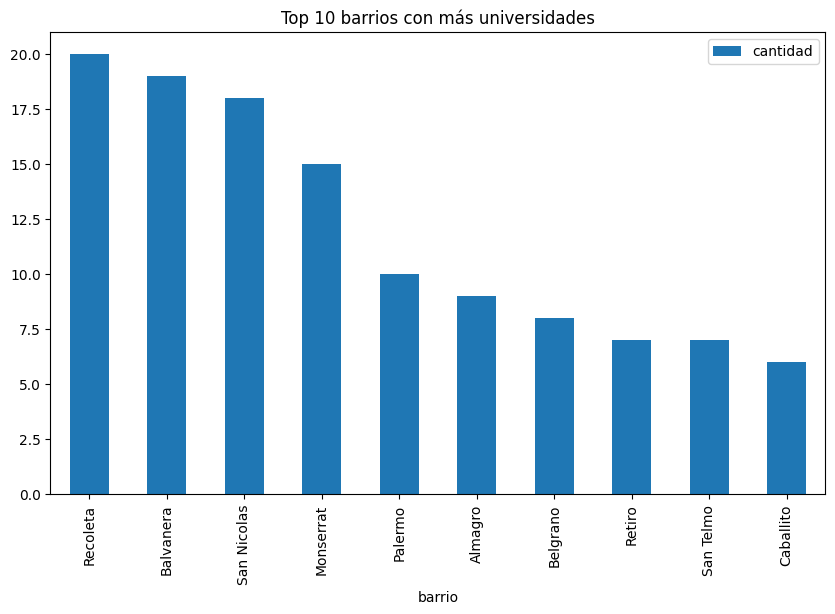

In [17]:
universidades_por_barrio.head(10).plot(
    x=col_barrio,
    y='cantidad',
    kind='bar'
)

plt.title('Top 10 barrios con más universidades')
plt.show()

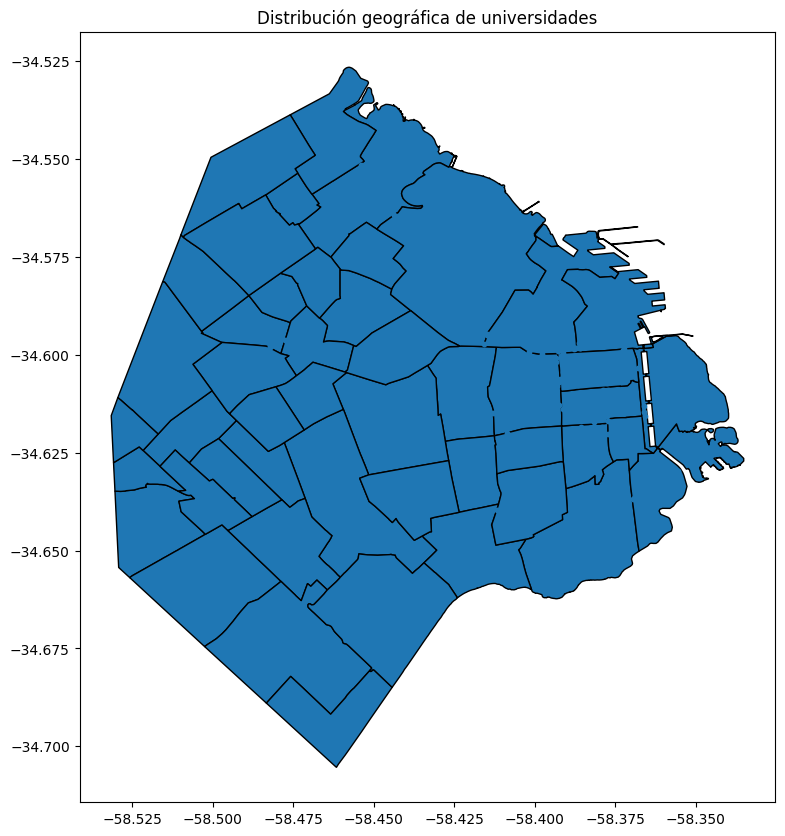

In [18]:
fig, ax = plt.subplots(figsize=(10,10))
barrios.plot(ax=ax, edgecolor='black')
universidades.plot(ax=ax, markersize=10)
plt.title('Distribución geográfica de universidades')
plt.show()

## Conclusiones

Completar con los resultados obtenidos al ejecutar el análisis. Describir qué barrios concentran más universidades y qué patrones se observan en la distribución espacial.